# 3_Cálculo del valor de decisión óptimo para el caso de una regla de decisión MAP en una observación discreta


## Consigna

Se transmite un símbolo binario $A \in \{0,1\}$ con probabilidades a priori

$$
P_A(0)=q, \qquad P_A(1)=1-q
$$

a través de un canal BSC. La observación $Y \in \{0,1\}$ también es binaria e igual a $A$ con probabilidad $1-p$.

1. Encuentre cualitativamente la regla de decisión MAP para el caso $q=0.9$ y $p=0.2$.
2. Encuentre cualitativamente la regla de decisión MAP para el caso $q=0.5$ y $p=0.3$.
3. A diferencia del caso ML, si suma todas las barras del histograma obtenido no van a obtener como resultado $1$. Intuir a qué se debe.
4. En cuál de los casos esta regla de decisión es óptima, es decir, cuándo produce la mínima probabilidad de error.
5. Realice y adjunte la simulación Monte Carlo del problema.


## Modelo BSC

El canal BSC, o **Binary Symmetric Channel**, conserva el bit con probabilidad $1-p$ y lo cambia con probabilidad $p$.

La tabla de probabilidades condicionadas es:

| Observación $y$ | $P_{Y\mid A}(y\mid 0)$ | $P_{Y\mid A}(y\mid 1)$ |
|---:|---:|---:|
| $0$ | $1-p$ | $p$ |
| $1$ | $p$ | $1-p$ |

Estas probabilidades son las verosimilitudes del canal. Para MAP también se incorporan las probabilidades a priori $P_A(0)=q$ y $P_A(1)=1-q$.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
rng = np.random.default_rng(20260508)


In [2]:
def map_scores(q, p):
    y_values = np.array([0, 1])
    score_a0 = np.array([q * (1 - p), q * p])
    score_a1 = np.array([(1 - q) * p, (1 - q) * (1 - p)])
    decisions = np.where(score_a0 >= score_a1, 0, 1)
    return y_values, score_a0, score_a1, decisions

def exact_error_probability(q, p, decisions):
    # Probabilidades conjuntas P(A=a, Y=y).
    joint = {
        (0, 0): q * (1 - p),
        (0, 1): q * p,
        (1, 0): (1 - q) * p,
        (1, 1): (1 - q) * (1 - p),
    }

    pe = 0.0
    for (a, y), prob in joint.items():
        if decisions[y] != a:
            pe += prob
    return pe

def print_map_table(q, p):
    y_values, score_a0, score_a1, decisions = map_scores(q, p)
    print(f"q = {q:.2f}, p = {p:.2f}")
    print("y   P(A=0)P(Y=y|A=0)   P(A=1)P(Y=y|A=1)   decision MAP")
    for y, s0, s1, decision in zip(y_values, score_a0, score_a1, decisions):
        print(f"{y}        {s0:.4f}                 {s1:.4f}             A_hat={decision}")
    print(f"Suma barras A=0: {score_a0.sum():.4f}")
    print(f"Suma barras A=1: {score_a1.sum():.4f}")
    print(f"Suma total de barras: {(score_a0.sum() + score_a1.sum()):.4f}")
    print(f"Pe exacta MAP: {exact_error_probability(q, p, decisions):.4f}")

def plot_map_scores(q, p, title):
    y_values, score_a0, score_a1, decisions = map_scores(q, p)
    width = 0.35
    x = np.arange(len(y_values))

    plt.figure(figsize=(8, 4))
    plt.bar(x - width / 2, score_a0, width, label=r"$P_A(0)P_{Y\mid A}(y\mid 0)$")
    plt.bar(x + width / 2, score_a1, width, label=r"$P_A(1)P_{Y\mid A}(y\mid 1)$")

    for idx, decision in enumerate(decisions):
        plt.text(idx, max(score_a0[idx], score_a1[idx]) + 0.015, fr"$\hat A={decision}$", ha="center")

    plt.xticks(x, y_values)
    plt.xlabel("Observación y")
    plt.ylabel("Probabilidad ponderada")
    plt.title(title)
    plt.legend()
    plt.ylim(0, max(score_a0.max(), score_a1.max()) * 1.25)
    plt.show()

def simulate_bsc_map(q, p, n_samples=300000, seed=1234):
    local_rng = np.random.default_rng(seed)
    a = np.where(local_rng.random(n_samples) < q, 0, 1)
    channel_error = local_rng.random(n_samples) < p
    y = np.bitwise_xor(a, channel_error.astype(int))
    _, _, _, decisions = map_scores(q, p)
    a_hat = decisions[y]
    pe_mc = np.mean(a_hat != a)
    return a, y, a_hat, pe_mc


## Regla MAP general

La regla MAP decide el símbolo que maximiza la probabilidad a posteriori:

$$
\hat A_{MAP}(y)=\arg\max_{a\in\{0,1\}} P_{A\mid Y}(a\mid y).
$$

Usando Bayes, como $P_Y(y)$ es común para ambas hipótesis, se compara:

$$
P_A(0)P_{Y\mid A}(y\mid 0)
\quad \text{contra} \quad
P_A(1)P_{Y\mid A}(y\mid 1).
$$

Es decir, se comparan las verosimilitudes ponderadas por las probabilidades a priori.

Para este BSC:

- si se observa $y=0$, se compara $q(1-p)$ contra $(1-q)p$;
- si se observa $y=1$, se compara $qp$ contra $(1-q)(1-p)$.


## 1. Caso $q=0.9$ y $p=0.2$

Datos:

$$
P_A(0)=q=0.9, \qquad P_A(1)=1-q=0.1
$$

$$
p=0.2, \qquad 1-p=0.8
$$

### Si se observa $y=0$

$$
P_A(0)P_{Y\mid A}(0\mid 0)=0.9\cdot0.8=0.72
$$

$$
P_A(1)P_{Y\mid A}(0\mid 1)=0.1\cdot0.2=0.02
$$

Como $0.72>0.02$, se decide $\hat A=0$.

### Si se observa $y=1$

$$
P_A(0)P_{Y\mid A}(1\mid 0)=0.9\cdot0.2=0.18
$$

$$
P_A(1)P_{Y\mid A}(1\mid 1)=0.1\cdot0.8=0.08
$$

Como $0.18>0.08$, también se decide $\hat A=0$.

Por lo tanto, para $q=0.9$ y $p=0.2$, la regla MAP es:

$$
\boxed{\hat A_{MAP}=0 \quad \text{para cualquier observación } y}
$$

La probabilidad a priori de $A=0$ es tan grande que conviene decidir $0$ incluso cuando se observa $Y=1$.


q = 0.90, p = 0.20
y   P(A=0)P(Y=y|A=0)   P(A=1)P(Y=y|A=1)   decision MAP
0        0.7200                 0.0200             A_hat=0
1        0.1800                 0.0800             A_hat=0
Suma barras A=0: 0.9000
Suma barras A=1: 0.1000
Suma total de barras: 1.0000
Pe exacta MAP: 0.1000


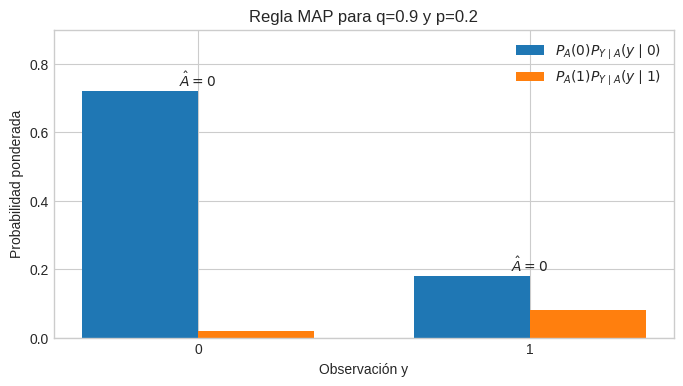

In [3]:
q1, p1 = 0.9, 0.2
print_map_table(q1, p1)
plot_map_scores(q1, p1, "Regla MAP para q=0.9 y p=0.2")


## 2. Caso $q=0.5$ y $p=0.3$

Datos:

$$
P_A(0)=q=0.5, \qquad P_A(1)=1-q=0.5
$$

$$
p=0.3, \qquad 1-p=0.7
$$

### Si se observa $y=0$

$$
P_A(0)P_{Y\mid A}(0\mid 0)=0.5\cdot0.7=0.35
$$

$$
P_A(1)P_{Y\mid A}(0\mid 1)=0.5\cdot0.3=0.15
$$

Como $0.35>0.15$, se decide $\hat A=0$.

### Si se observa $y=1$

$$
P_A(0)P_{Y\mid A}(1\mid 0)=0.5\cdot0.3=0.15
$$

$$
P_A(1)P_{Y\mid A}(1\mid 1)=0.5\cdot0.7=0.35
$$

Como $0.35>0.15$, se decide $\hat A=1$.

Por lo tanto, para $q=0.5$ y $p=0.3$, la regla MAP es:

$$
\boxed{\hat A_{MAP}=Y}
$$

En este caso MAP coincide con ML, porque las probabilidades a priori son iguales.


q = 0.50, p = 0.30
y   P(A=0)P(Y=y|A=0)   P(A=1)P(Y=y|A=1)   decision MAP
0        0.3500                 0.1500             A_hat=0
1        0.1500                 0.3500             A_hat=1
Suma barras A=0: 0.5000
Suma barras A=1: 0.5000
Suma total de barras: 1.0000
Pe exacta MAP: 0.3000


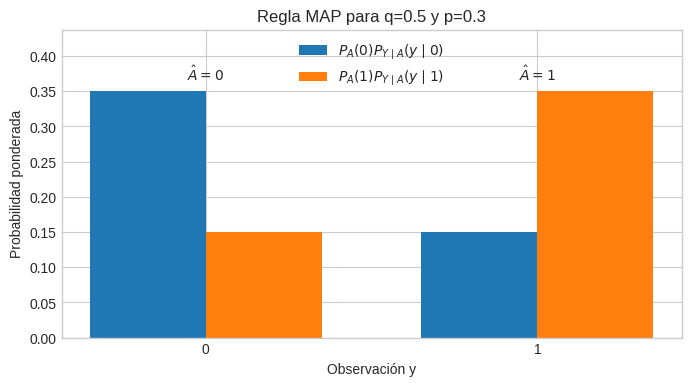

In [4]:
q2, p2 = 0.5, 0.3
print_map_table(q2, p2)
plot_map_scores(q2, p2, "Regla MAP para q=0.5 y p=0.3")


## 3. Por qué las barras no necesariamente suman $1$

En ML se grafican verosimilitudes como $P_{Y\mid A}(y\mid a)$. Para un valor fijo de $a$, esas probabilidades sí forman una distribución sobre $Y$, por eso:

$$
\sum_y P_{Y\mid A}(y\mid a)=1.
$$

En MAP se grafican cantidades ponderadas por la probabilidad a priori:

$$
P_A(a)P_{Y\mid A}(y\mid a).
$$

Eso ya no es una distribución condicional de $Y$ dado $A=a$: es una probabilidad conjunta $P(A=a,Y=y)$.

Por eso, si se suman las barras correspondientes a una sola hipótesis, se obtiene la probabilidad a priori de esa hipótesis:

$$
\sum_y P_A(a)P_{Y\mid A}(y\mid a)=P_A(a).
$$

Por ejemplo, para $q=0.9$:

$$
\sum_y P_A(0)P_{Y\mid A}(y\mid 0)=P_A(0)=0.9,
$$

$$
\sum_y P_A(1)P_{Y\mid A}(y\mid 1)=P_A(1)=0.1.
$$

Si se suman todas las barras de ambas hipótesis y todas las observaciones, sí se obtiene $1$, porque se recorren todos los pares posibles $(A,Y)$.


## 4. En qué casos la regla MAP es óptima

La regla MAP es óptima en ambos casos, siempre que el objetivo sea minimizar la probabilidad de error y que las probabilidades a priori sean conocidas.

La diferencia importante es:

- en el punto 1, MAP no coincide con ML, porque $q=0.9$ y las probabilidades a priori no son iguales;
- en el punto 2, MAP coincide con ML, porque $q=0.5$ y las probabilidades a priori son iguales.

Para el punto 1, la regla MAP decide siempre $0$ y obtiene:

$$
P_e=P(A=1)=0.1.
$$

Si en ese mismo caso se usara ML, se decidiría $\hat A=Y$ y la probabilidad de error sería $p=0.2$. Entonces MAP mejora el desempeño.

Para el punto 2, como MAP coincide con ML y $\hat A=Y$:

$$
P_e=p=0.3.
$$


## 5. Simulación Monte Carlo

La simulación sigue estos pasos:

1. generar muchos símbolos $A$ con $P_A(0)=q$ y $P_A(1)=1-q$;
2. pasarlos por un BSC con probabilidad de cruce $p$;
3. aplicar la regla MAP;
4. contar la frecuencia relativa de errores.


In [5]:
for idx, (q, p) in enumerate([(q1, p1), (q2, p2)], start=1):
    _, _, _, decisions = map_scores(q, p)
    pe_exact = exact_error_probability(q, p, decisions)
    a_tx, y_rx, a_hat, pe_mc = simulate_bsc_map(q, p, seed=20260508 + idx)

    print(f"Caso {idx}: q={q:.1f}, p={p:.1f}")
    print(f"Regla MAP: si y=0 -> A_hat={decisions[0]}, si y=1 -> A_hat={decisions[1]}")
    print(f"Frecuencia A=0 simulada: {np.mean(a_tx == 0):.4f}")
    print(f"Frecuencia A=1 simulada: {np.mean(a_tx == 1):.4f}")
    print(f"Pe exacta:      {pe_exact:.4f}")
    print(f"Pe Monte Carlo: {pe_mc:.4f}")
    print()


Caso 1: q=0.9, p=0.2
Regla MAP: si y=0 -> A_hat=0, si y=1 -> A_hat=0
Frecuencia A=0 simulada: 0.9000
Frecuencia A=1 simulada: 0.1000
Pe exacta:      0.1000
Pe Monte Carlo: 0.1000

Caso 2: q=0.5, p=0.3
Regla MAP: si y=0 -> A_hat=0, si y=1 -> A_hat=1
Frecuencia A=0 simulada: 0.4996
Frecuencia A=1 simulada: 0.5004
Pe exacta:      0.3000
Pe Monte Carlo: 0.3019



## Resumen final

Para el caso $q=0.9$ y $p=0.2$:

$$
\boxed{\hat A_{MAP}=0 \quad \text{para } y=0 \text{ y para } y=1}
$$

$$
\boxed{P_e=0.1}
$$

Para el caso $q=0.5$ y $p=0.3$:

$$
\boxed{\hat A_{MAP}=Y}
$$

$$
\boxed{P_e=0.3}
$$

La regla MAP es óptima en ambos casos. Cuando las probabilidades a priori son iguales, MAP coincide con ML; cuando no son iguales, MAP puede tomar una decisión distinta porque incorpora esa información previa.
